# Chapitre 4 : Entanglement in action

Content:
1. Quantum Teleportation
2. Superdense Coding
3. The CHSH game
4. Implementation on Qiskit

Remind: entangled state, it's an state which cannot be decompose into product of states. 
Example:
- Bell state: $|\phi^+\rangle = \frac{1}{\sqrt{2}}|00\rangle+\frac{1}{\sqrt{2}}|11\rangle$
- Probabilistic state of this state: $|\phi^+\rangle = \frac{1}{2}|00\rangle+\frac{1}{2}|11\rangle$

In quantum computing, entanglement is typically viewed as a resource. An entangled quantum state such as the Bell state is called an $e$-bit.

Terminology: In the following, when we say that Alice and Bob share an $e$-bit, it means that Alice has a qubit $A$, Bob has a qubit $B$, and the pair $(A,B)$ is in the Bell state $|\phi^+\rangle$.

## 1. Quantum teleportation
Quantum teleportation is a protocol that allows information to be transmitted from a sender to a receiver solely through quantum entanglement and quantum communication. (This has nothing to do with the teleportation of matter.) Below the scheme of the circuit:

<div align="center">
    <img src="../Images/BasicOfQuantumInformation/CHSH_game_protocol.png" alt="Capture" width="600"/>
</div>

Scenario:
- Alice has a qubit that she wants to transmit to Bob.
- Alice cannot physically transmit the information to Bob. She can only send classical information. 
- Alice and Bob share an e-bit.

The disadvantage of classical information is that it can be easily copied and disseminated. 
- The state of the qubit $Q$ is unknown to Bob and Alice.
- The correlation (including entanglement) between $Q$ and the other systems must be preserved by the transmission.
- The no-cloning theorem implies that if Bob receives the transmission, Alice no longer has the qubit in its original state.

Protocol:
`
1. Alice performs a $CNOT$ operation, where $Q$ is the control bit and $A$ is the target bit.
2. Alice performs a Hadamard operation on $Q$.
3. Alice measures $A$ and $Q$, obtaining binary outputs $a$ and $b$, respectively.
4. Alice sends $a$ and $b$ to Bob.
5. Bob performs two operations:
1. If $a = 1$, then Bob performs the $X$ operation on qubit $B$.
2. If $b = 1$, then Bob performs the $Z$ operation on qubit $B$.

Operations performed by Bob:
$$I \text{ if } ab = 00$$
$$Z \text{ if } ab = 01$$
$$X \text{ if } ab = 10$$
$$ZX \text{ if } ab = 11$$

Protocol analysis:
$Q$ in in the state:
$$ \alpha|0\rangle+\beta|1\rangle$$
The state before the $CNOT$ gate $|\pi_0\rangle$ is :
$$|\pi_0\rangle = \frac{\alpha|000\rangle + \alpha|110\rangle + \beta|001\rangle + \beta|111\rangle}{\sqrt{2}} $$

The state after the $CNOT$ gate and before $H$ gate $|\pi_1\rangle$ is :
$$|\pi_1\rangle = \frac{\alpha|000\rangle + \alpha|110\rangle + \beta|011\rangle + \beta|101\rangle}{\sqrt{2}}$$


The state after the $H$ gate $|\pi_2\rangle$ is :
$$|\pi_2> = \frac{\alpha|00>|+\rangle + \alpha|11>|+\rangle + \beta|01\rangle|-\rangle + \beta|10\rangle|-\rangle }{\sqrt{2}} $$
$$|\pi_2> = \frac{1}{2}(\alpha|0\rangle+\beta|1\rangle)|00\rangle +\frac{1}{2}(\alpha|0\rangle-\beta|1\rangle)|01\rangle+\frac{1}{2}(\alpha|1\rangle+\beta|0\rangle)|10\rangle+\frac{1}{2}(\alpha|1\rangle-\beta|0\rangle)|11\rangle$$


and therefore the probability of obtaining the quantum information is:
$$P(ab = 00) = \frac{1}{4}\parallel\alpha|0\rangle+\beta|1\rangle\parallel^2 = \frac{1}{4} $$
$$P(ab = 01) = \frac{1}{4}\parallel\alpha|0\rangle-\beta|1\rangle\parallel^2 = \frac{1}{4} $$
$$P(ab = 10) = \frac{1}{4}\parallel\alpha|1\rangle+\beta|0\rangle\parallel^2 = \frac{1}{4} $$
$$P(ab = 11) = \frac{1}{4}\parallel\alpha|1\rangle-\beta|0\rangle\parallel^2 = \frac{1}{4}$$

The operations applied by Bob allow the qubit to be converted back to its original state.
Quantum teleportation is not an application of quantum information; it is a means of performing quantum communication. 
Quantum teleportation motivates distillation by entanglement as a means of reliable quantum communication. Indeed, no copying is possible. 
Beyond its potential for communication, teleportation is fundamentally important for the study of quantum information as well as for computing.

## 2. Codage superdense
Allows the communication of two conventional bits to be condensed into a single qubit.

Scenario 

Alice has two classical bits that she wants to transmit to Bob.

- Alice is able to send a single qubit to Bob.
- Alice and Bob share an e-bit.

Without the e-bit, the task would be impossible.

Holevo's theorem implies that two classical bits of communication cannot be reliably transmitted by a single qubit. (See end of this section.)

Holevo's theorem:

An important limiting theorem in quantum computing. It is sometimes called Holevo's bound because it sets an upper limit on the amount of information accessible on a quantum state. It will be introduced in the discussion of quantum noise processing. (Link to von Neumann entropy).


<div align="center">
    <img src="../Images/BasicOfQuantumInformation/superdense_coding.png" alt="Capture" width="600"/>
</div>


here is what Alice does:
1. If $d=1$, Alice performs $Z$ gate on her qubit $A$ (and if $d=0$ she does not)
2. If $c=1$, Alice performs $X$ gate on her qubit $A$ (and if $c=0$ she does not)

Alice then sends her qubit $A$ to Bob. What Bob does when he receives the qubit $A$ is to first perform a controlled-NOT gate, with 
$A$ being the control and $B$ being the target, and then he applies a Hadamard gate to $A$. He then measures $B$ to obtain $c$ and 
$A$ to obtain $d$, with standard basis measurements in both cases. (it's equivalent to analys the Bell state received by Bob)

Superdense coding seems unlikely to be useful in practice for data transmission. Indeed, classical data transmission is currently inexpensive compared to quantum transmission.

The underlying idea is not fundamentally important, and merely illustrates one aspect of entanglement.

The concept is equivalent to quantum teleportation.

## 3. CHSH Game

The letters refer to their authors John Clauser, Michael Horne, Abner Shimony, and Richard Holt. Reference to CHSH inequality.

The mathematical abstractions of games are both important and useful. The example of the CHSH game is an example of a nonlocal game.

Setup:

Players Alice and Bob play as a team. The game is started by a referee. Alice and Bob can prepare for the match as they wish. However, once the game has started, they are not allowed to communicate. They are separated by a large distance. 

The referee asks each of them a question. Alice's question is denoted by $X$, and Bob's question is denoted by $Y$. $X$ and $Y$ are classical bits. Alice's answer is $a$, and Bob's answer is $b$. Both are classical.

What does the referee do? He chooses $X$ and $Y$ at random. The referee determines whether a pair of answers $(a, b)$ is correct or incorrect for the pair of questions $(X, Y)$ according to fixed rules. A precise description of the referee defines an example of a non-local game.

<div align="center">
    <img src="../Images/BasicOfQuantumInformation//CHSH_game_protocol.png" alt="Capture" width="500"/>
</div>

The referee of the CHSH game is defined as follows:
1. The questions and answers are classical bits. 
2. Questions $X$ and $Y$ are chosen randomly in a uniform manner. 
3. Pairs of answers $(a,b)$ win for $(X,Y)$ if 
    
    $$
    a\oplus b=x\wedge y
    $$
    otherwise they lose. Use of the exclusive $OR$ $\oplus$ operator: if at least one of the two answers is $0$, then the result is $0$.


| (X,Y)  | Condition to win |
| :--------------- |:---------------:|
| (0,0)  |$a =b$|
| (0,1)  |$a =b$|
| (1,0)  |$a =b$|
| (1,1)  |$a \neq b$|

Deterministic strategy: Such a strategy cannot win every time.
$$a(0)\oplus b(0)=0 $$
$$a(0)\oplus b(1)=0 $$
$$a(1)\oplus b(0)=0 $$
$$a(1)\oplus b(1)=1 $$

By adopting a deterministic strategy, probability of winning = 75%

Probabilistic strategy: A probabilistic strategy can be seen as a random choice compared to a deterministic strategy. A random strategy cannot win against a deterministic strategy. What about a quantum strategy?
	
let's pose:
$$|\psi_0\rangle = cos(\theta)|0\rangle+sin(\theta)|1\rangle$$

Using the angle addition formula:
$$\langle\psi_\alpha|\psi_\beta\rangle = cos(\alpha)cos(\beta)+sin(\alpha)sin(\beta)=cos(\alpha-\beta) $$                  $$\langle\psi_\alpha\otimes\psi_\beta|\phi^+\rangle = \frac{cos(\alpha)cos(\beta)+sin(\alpha)sin(\beta)}{\sqrt{2}} = \frac{cos(\alpha-\beta)}{\sqrt{2}}$$

Let's define a unit matrix:
$$U_{\theta} = |0\rangle\langle\psi_\theta|+|1\rangle\langle\psi_{\theta+\pi/2}|$$

Alice and Bob's strategy:
- Alice and Bob share an ebit (A,B)
  
Alice's action:
- Alice applies an operation to A such that:
$$\begin{equation}
    \left\{ 
        \begin{array}{cc}
                U_0 & \text{si } x=0 \\ U_{\pi/4} & \text{si } x=1          
    	\end{array}
    \right .
\end{equation}$$
Then she measures A and sends the result to the referee.
Bob applies the operation to B as follows:
$$\begin{equation}
    \left\{ 
        \begin{array}{cc}
                U_{\pi/8} & \text{si } y=0 \\ U_{-\pi/4} & \text{si } y=1 
    	\end{array}
    \right .
\end{equation}$$

Then he measures B and sends the result to the referee.

The choice of angles is judicious but not obvious.
Strategy analysis:
$$U_{\theta} = |0\rangle\langle\psi_\theta|+|1\rangle\langle\psi_{\theta+\pi/2}| $$
$$\langle\psi_\alpha\otimes\psi_\beta|\phi^+\rangle = \frac{cos(\alpha)cos(\beta)+sin(\alpha)sin(\beta)}{\sqrt{2}} = \frac{cos(\alpha-\beta)}{\sqrt{2}}$$

Case : $(X,Y) = (0,0)$:
Alice performs $U_0$ and Bob performs $U_{\pi/8}$:

$$(U_0\otimes U_{\pi/8}|\phi^+\rangle =$$
$$|00\rangle\langle\psi_0\otimes \psi_{\pi/8}|\phi^+\rangle + |01\rangle\langle\psi_0\otimes \psi_{5\pi/8}|\phi^+\rangle + |10\rangle\langle\psi_{\pi/2}\otimes \psi_{\pi/8}|\phi^+\rangle +|11\rangle\langle\psi_{\pi/2}\otimes \psi_{5\pi/8}|\phi^+\rangle =$$
$$\frac{cos(-\frac{\pi}{8})|00\rangle+cos(-\frac{5\pi}{8})|01\rangle+cos(\frac{3\pi}{8})|10\rangle+cos(-\frac{\pi}{8})|11\rangle}{\sqrt{2}}$$


| (a,b)  | Probability | Simplified |
| :--------------- |:---------------:|:---------------:|
| (0,0)  |$\frac{1}{2}cos^2(-\frac{\pi}{8})$|$\frac{2+\sqrt{2}}{8}$|
| (0,1)  |$\frac{1}{2}cos^2(\frac{5\pi}{8})$|$\frac{2-\sqrt{2}}{8}$|
| (1,0)  |$\frac{1}{2}cos^2(\frac{3\pi}{8})$|$\frac{2-\sqrt{2}}{8}$|
| (1,1)  |$\frac{1}{2}cos^2(-\frac{\pi}{8})$|$\frac{2+\sqrt{2}}{8}$|

$$P(a=b) = \frac{2+\sqrt{2}}{4} \approx 0.85$$
$$P(a\neq b) = \frac{2-\sqrt{2}}{4} \approx 0.15$$

In this case, the corresponding winning rate is approximately $0.85$, while the losing rate is approximately $0.15$, which is higher than the deterministic strategy. For other cases, the development is similar.

Note:

The CHSH game is not always referred as a game; it is often described as an experiment or a Bell example. Some people sometimes refer to it as a Bell test because this example is related to Bell's theorem, which can be formulated differently: quantum mechanics is not compatible with the theory of local hidden variables (local hidden variable theories)

The CHSH game provides an experimental means of testing quantum information theory.

The study of non-local games more generally is a fascinating and active area of research that continues to hold mysteries.

## 4. Implementation on Qiskit

In [1]:
# modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from numpy import pi, random

### Quantum Teleportation

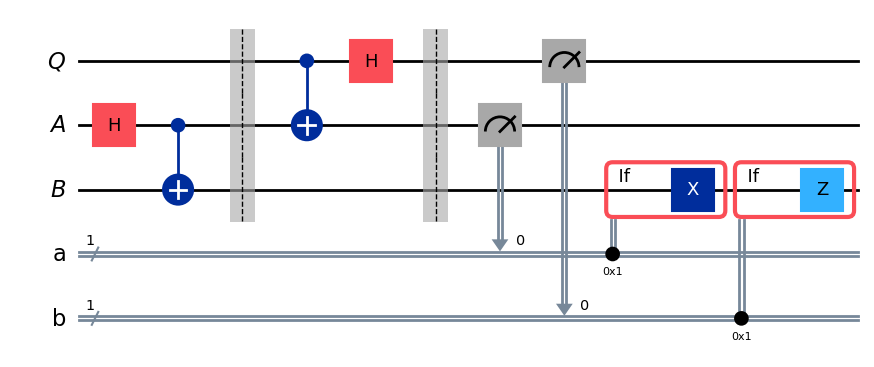

In [3]:
# Varibales
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# prepare ebit used for teleportation (State before Barrier)
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice operation
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measure and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)


# Bob uses the classical bits to condionally apply gates
# zpplication de la porte X si a=1
with protocol.if_test((a,1)):
        protocol.x(ebit1)

#application de la pore Z si b=1
with protocol.if_test((b,1)):
        protocol.z(ebit1)

display(protocol.draw(output="mpl"))

In [4]:
# Generator to get a random qubit
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

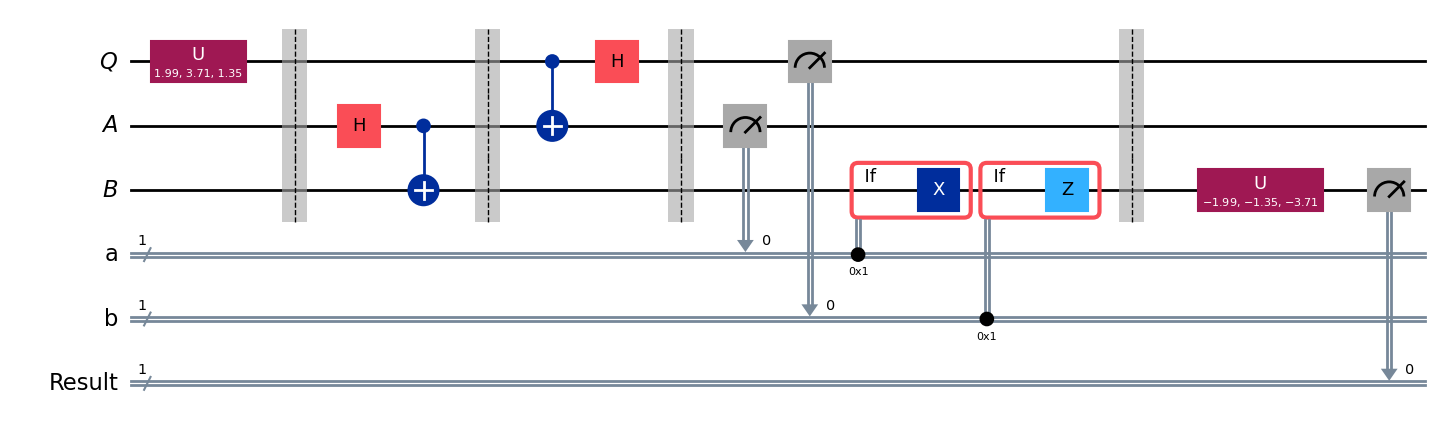

In [5]:
# Now let's try to get the random qubit with the Quantum Teleportation protocol

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Q initialisation
test.append(random_gate, qubit)
test.barrier()

# add the QP protocol 
test = test.compose(protocol)
test.barrier()


# Apply the inverse of unitary gate to B, and measure.
# the application of the inverse allow to check if we had the state |0>
test.append(random_gate.inverse(), ebit1)
result = ClassicalRegister(1, "Result")
test.add_register(result)
test.measure(ebit1, result)

display(test.draw(output="mpl"))

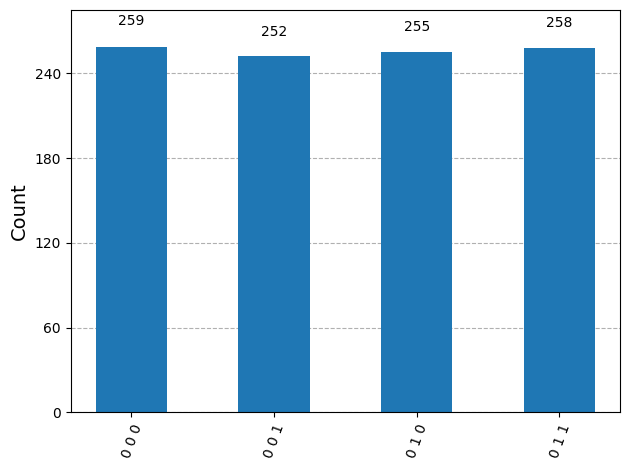

In [6]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()

# le qubit le plus à gauche est toujours 0, format du résulat = [Result, b, a]
# The most left qubit is always equal to 0. Result format = [Result, b, a]
# It's allow to check that the qubit is well teleported
display(plot_histogram(statistics))

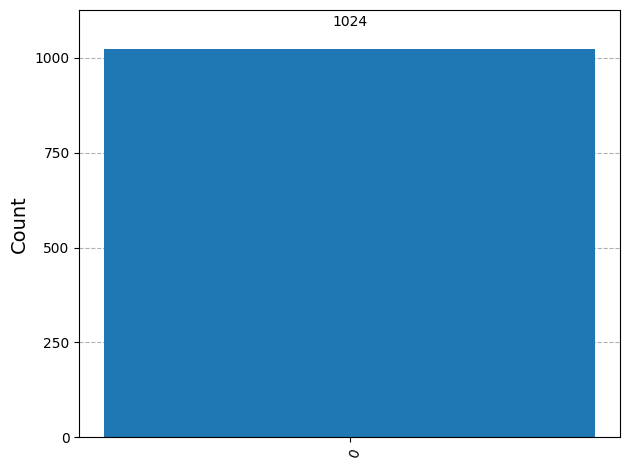

In [7]:
# We can add a filter to view only the needed result. 
# Here the filtered information can be viewed when all the results are equal to 0.
filtered_statistics = marginal_distribution(statistics, [2])
display(plot_histogram(filtered_statistics))

### Superdense Coding

In [8]:
# exemple of data to transmit
c = "1"
d = "0"

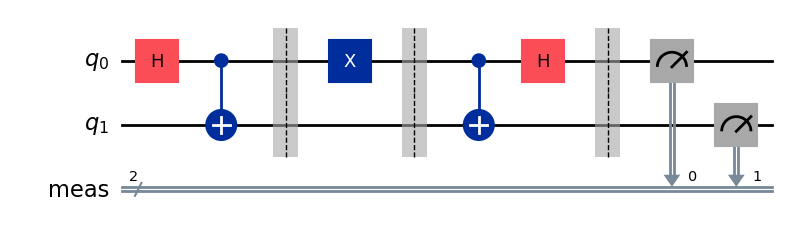

In [9]:
protocol = QuantumCircuit(2)

# Preparation of the e-bit to share
protocol.h(0)
protocol.cx(0,1)
protocol.barrier()

# Alice's operation
if d=="1":
    protocol.z(0)
if c=="1":
    protocol.x(0)
protocol.barrier()

# Bob's action
protocol.cx(0,1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

Measured 10 with frequency 1024


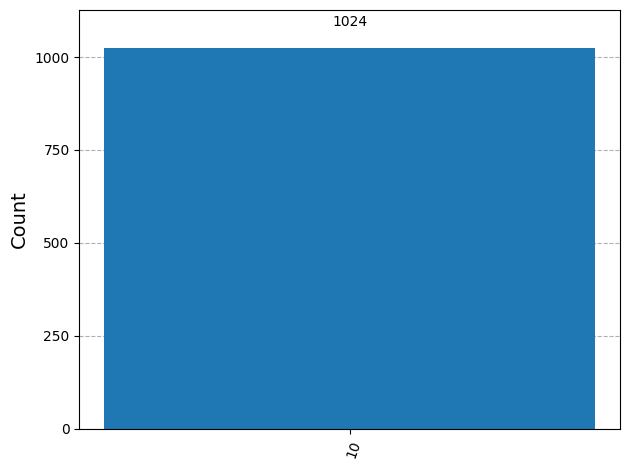

In [10]:
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

# result under the format [cd]
display(plot_histogram(statistics))

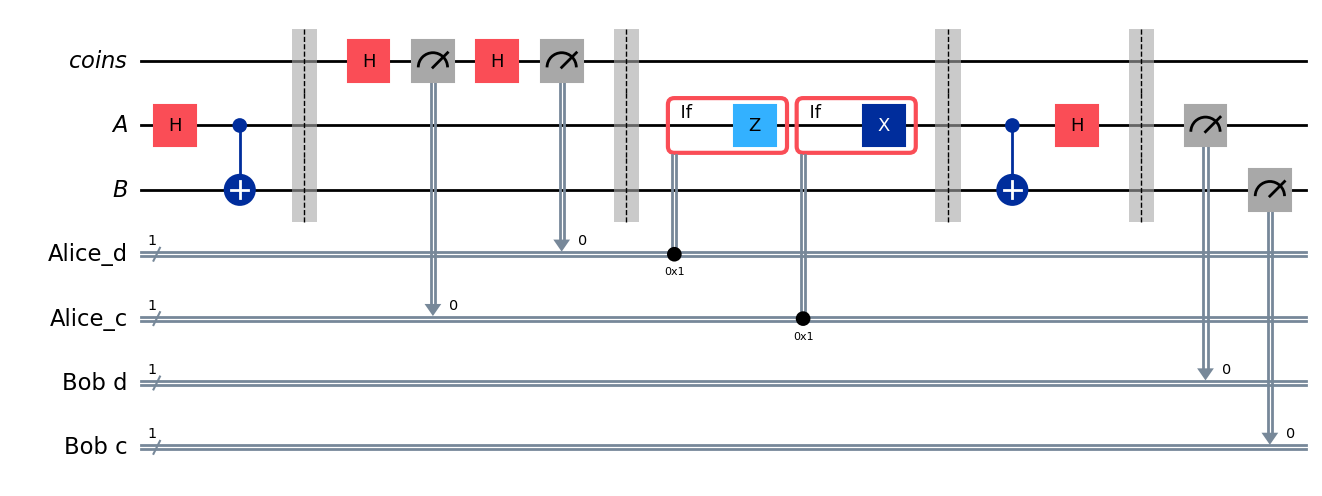

In [12]:
# Now let's try with a random bit generator
rbg = QuantumRegister(1, "coins")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice_c")
Alice_d = ClassicalRegister(1, "Alice_d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# initialisation
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# Generation of two random bits c and d for Alice with Coins.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Now the protocol run, let's begin with Alice actions which depend of her values
with test.if_test((Alice_d, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"):
    test.x(ebit0)
test.barrier()

# Bob actions
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))

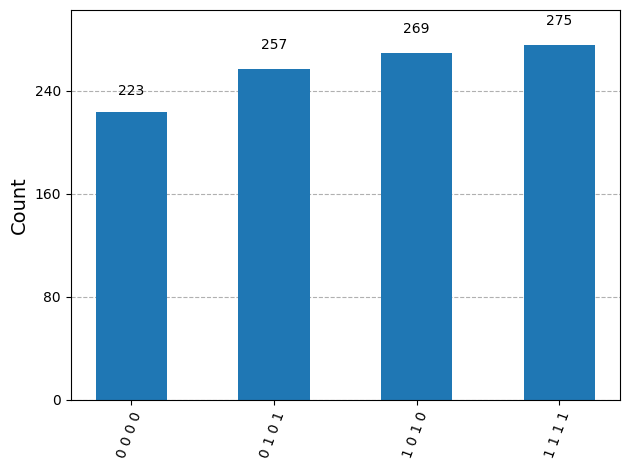

In [13]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))
# Results under the format [Ad, Ac, Bd, Bc]

### CHSH Game

In [14]:
def chsh_game(strategy):
    # This function runs the CHSH game, using the strategy (a function
    # from two bits to two bits), returning 1 for a win and 0 for a loss.

    # Choose x and y randomly
    x, y = random.randint(0, 2), random.randint(0, 2)

    # Use the strategy to determine a and b
    a, b = strategy(x, y)

    # Decide if the strategy wins or loses
    if (a != b) == (x & y):
        return 1  # Win
    return 0  # Lose

In [15]:
def chsh_circuit(x, y):
    # This function creates a `QuantumCircuit` implementing the quantum
    # strategy described above (including the e-bit preparation).

    qc = QuantumCircuit(2, 2)

    # Prepare an e-bit
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # Alice's actions
    if x == 0:
        qc.ry(0, 0)
    else:
        qc.ry(-pi / 2, 0)
    qc.measure(0, 0)

    # Bob's actions
    if y == 0:
        qc.ry(-pi / 4, 1)
    else:
        qc.ry(pi / 4, 1)
    qc.measure(1, 1)

    return qc

(x,y) = (0,0)


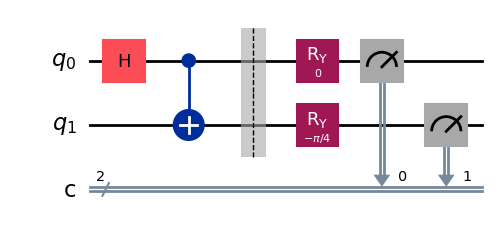

(x,y) = (0,1)


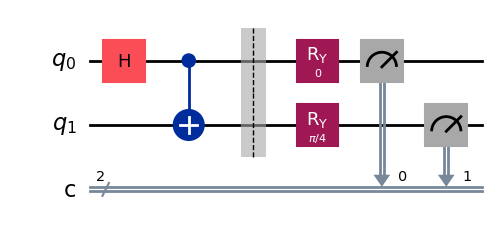

(x,y) = (1,0)


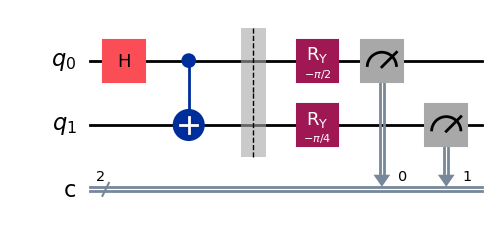

(x,y) = (1,1)


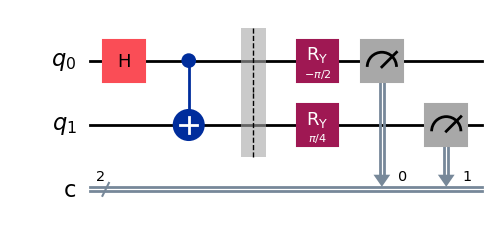

In [16]:
# Draw the four possible circuits

print("(x,y) = (0,0)")
display(chsh_circuit(0, 0).draw(output="mpl"))

print("(x,y) = (0,1)")
display(chsh_circuit(0, 1).draw(output="mpl"))

print("(x,y) = (1,0)")
display(chsh_circuit(1, 0).draw(output="mpl"))

print("(x,y) = (1,1)")
display(chsh_circuit(1, 1).draw(output="mpl"))

In [17]:
def quantum_strategy(x, y):
    # This function runs the appropriate quantum circuit defined above
    # one time and returns the measurement results

    # Setting `shots=1` to run the circuit once
    result = AerSimulator().run(chsh_circuit(x, y), shots=1).result()
    statistics = result.get_counts()

    # Determine the output bits and return them
    bits = list(statistics.keys())[0]
    a, b = bits[0], bits[1]
    return a, b

In [18]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(quantum_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.859


In [19]:
def classical_strategy(x, y):
    # This function implements just one example of an optimal classical
    # strategy for the CHSH game. Other classical strategies can be
    # implemented by changing the bit values assigned to a and b.

    # Alice's answer
    if x == 0:
        a = 0
    elif x == 1:
        a = 1

    # Bob's answer
    if y == 0:
        b = 1
    elif y == 1:
        b = 0

    return a, b

In [20]:
NUM_GAMES = 1000
TOTAL_SCORE = 0

for _ in range(NUM_GAMES):
    TOTAL_SCORE += chsh_game(classical_strategy)

print("Fraction of games won:", TOTAL_SCORE / NUM_GAMES)

Fraction of games won: 0.74


We can see that the probabilistic method has a success rate of 85% against 75% for the classical method.